# Bepaling van warmtecapaciteit van een onbekend materiaal


# Introductie

Onbekende materialen kunnen geïdentificeerd worden door hun eigenschappen te meten. Een van deze eigenschappen is de warmtecapaciteit. In dit practicum gaan we de warmtecapaciteit van een onbekend materiaal bepalen door middel van een calorimeter experiment. Daarbij wordt een bepaalde massa van het materiaal naar een bekende temperatuur gebracht waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaatst. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend.

# Theorie

De soortelijke warmte $c$ van een materiaal is gedefinieerd als de hoeveelheid warmte $Q$ die nodig is om de temperatuur $T$ van een kilogram van het materiaal met één graad Celsius (of één Kelvin) te verhogen:

$$
    c = \frac{Q}{m \Delta T}
$$ (eq:heat_capacity)

Waarbij $Q$ de hoeveelheid warmte in Joules is, $m$ de massa in kilogram is en $\Delta T$ de verandering in temperatuur is. Gegeven de wet van Black, die stelt dat de totale hoeveelheid warmte in een geïsoleerd systeem constant blijft, kunnen we de warmte die het onbekende materiaal verliest gelijkstellen aan de warmte die het water opneemt:

$$
    Q_{materiaal} = -Q_{water} 
$$ (eq:black)

wanneer we de massa's en de begintemperaturen van beide systemen kennen, maar slechts een van de twee soortelijke warmtes, kunnen we de onbekende soortelijke warmte berekenen. We combineren vergelijkingen [](#eq:heat_capacity) en [](#eq:black) om de volgende vergelijking te krijgen:

$$
    T_e = \frac{c_w m_w T_{w,b}+c_m m_m T_{m,b}}{c_w m_w + c_m m_m}
$$ (eq:combined)

Waarbij de subscripts $b$ en $e$ respectievelijk staan voor begintoestand en eindtoestand, $w$ voor water en $m$ voor het onbekende materiaal.

Bij metingen aan verschillende massa's van het onbekende materiaal en vervolgens een least square fit aan bovenstaande vergelijking kunnen we een precieze waarde voor de soortelijke warmte van het onbekende materiaal bepalen. Dat is, wanneer de warmtecapaciteit van bijvoorbeeld de beker te verwaarlozen is.


# Methode en materialen

## Ontwerp
De bovenstaande theorie wordt gebruikt om de soortelijke warmte van een onbekend materiaal te bepalen. Het experiment bestaat uit het verwarmen van verschillende massa's van het onbekende materiaal tot een bekende temperatuur, waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaats. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend. Om de tijd voor het meten van meerdere materialen te reduceren, worden de data van de verschillende groepen in het lokaal samengevoegd. Van tevoren is afgesproken welke massa's door welke groep worden gemeten, en hoeveel water er gebruikt wordt.

## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Calorimeter
- Thermometer of temperatuursensor
- Verwarmingsbron 
- Diverse massablokjes van onbekend materiaal
- Weegschaal
- Water
- Maatcilinder of maatbeker


```{figure} figures/c_onbekend_setup.jpg
:width: 70%
:label: fig_c_onbekend_setup

Een schematische weergave van de opstelling
```


## Procedure
Bespreek wie welke massa's van het onbekende materiaal gaat meten.
Bespreek ook hoeveel water er gebruikt gaat worden.
Bepaal de begintemperaturen.
Hevel het aantal afgesproken massa's in de maatbeker. 
Roer voorzicht zodat de temperatuur homogeen is.
Noteer de hoogste gemeten temperatuur, dit is $T_e$.
Wissel de metingen uit met de andere groepen en voer de data-analyse uit.

```{note}
Hieronder staat een voorbeeld hoe je een grafiek moet opslaan en vervolgens in je document kunt oproepen.
Het voorbeeld kun je natuurlijk straks verwijderen.
```

# Resultaten


In [2]:
# Sla figuren op met  
# 
# plt.savefig("Figuren/naam.png", dpi=450)
# waarbij naam vervangen wordt door de bestandsnaam. 
# Onderstaande voorbeeld code en output grafiek 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Massa 
m_beker = 0.1304 #kg
m_tot = 0.2555 #kg
m_water = m_tot-m_beker

# Massa van een blokje
m_blokje = 0.050 #kg
T_blokje_0 = 68.9 + 273.15 #K

T_water_0 = np.array([19.1,21.1,24.1,27.1,31.0]) + 273.15 #K
T_water_max = np.array([21.1,24.3,27.9,32.0,35.9]) +273.15 #K
M_blokjes = np.array([m_blokje,2*m_blokje,3*m_blokje,4*m_blokje,5*m_blokje]) #kg

# Massas kleine maatbeker
m_beker_klein = 0.0432 #kg
m_tot_klein = 0.1165 #kg
m_water_klein = m_tot_klein-m_beker_klein

T_water_0_klein = np.array([20.1,23.0,27.2]) + 273.15 #K
T_water_max_klein = np.array([23.3,28.2,34.6]) + 273.15 #K
M_blokjes_klein = np.array([m_blokje,m_blokje*2,m_blokje*3]) #kg

c_water = 4186 #J/KgK

# Combined lists
T_water_0 =     np.concatenate((T_water_0,T_water_0_klein))
T_water_max =   np.concatenate((T_water_max,T_water_max_klein))
M_water =       np.array([m_water,m_water,m_water,m_water,m_water, m_water_klein,m_water_klein,m_water_klein])
M_blokjes =     np.concatenate((M_blokjes,M_blokjes_klein))

pred_array = np.array([T_water_0,M_water,M_blokjes]) #combeneren van variabele aan de rechterkand van de vergelijking

In [14]:
#fit functie op basis van de vergelijking voor T_e
def func(x_array,c_m):
    return (c_water*x_array[1,:]*x_array[0,:] + c_m*x_array[2,:]*T_blokje_0)/(c_water*x_array[1,:] + c_m*x_array[2,:])

var, cov = curve_fit(func, pred_array, T_water_max) #curve fit uitvoeren

print(f' De soortelijke warmte van het onbekende materiaal is: {var[0]:.1e} +/- {np.sqrt(cov[0,0]):.0e} J/KgK.')

 De soortelijke warmte van het onbekende materiaal is: 3.7e+02 +/- 2e+01 J/KgK.


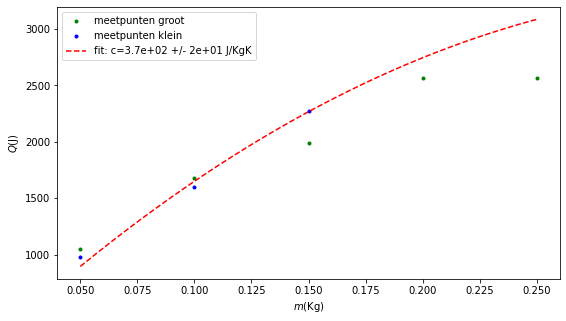

In [15]:
#netto warmte opnamen van het water berekenen
delta_T = T_water_max-T_water_0
Q_water = c_water*delta_T*M_water

#test arrays aanmaken voor het plotten
M_blokjes_test = np.linspace(min(M_blokjes),max(M_blokjes),1000)
T_water_max_test = np.linspace(min(T_water_max),max(T_water_max),1000)

#netto afsgestane warmte door de blokjes berekenen op basis van de gefitte waarde voor c_m
delta_T_blokjes = T_blokje_0 -T_water_max_test
Q_blokjes = var[0]*M_blokjes_test*delta_T_blokjes

#warte tegen massa van de blokjes plotten
plt.figure(figsize=(9,5))
plt.plot(M_blokjes[0:5],Q_water[0:5],'g.',label='meetpunten groot')
plt.plot(M_blokjes[5:8],Q_water[5:8],'b.',label='meetpunten klein')
plt.plot(M_blokjes_test,Q_blokjes,'r--', label=f'fit: c={var[0]:.1e} +/- {np.sqrt(cov[0,0]):.0e} J/KgK')
plt.xlabel('$m \mathrm{(Kg)}$')
plt.ylabel('$Q \mathrm{(J)}$')
plt.legend()
plt.savefig("../../Figures/onbekende_warmtecapaciteit.png", dpi=450)
plt.show()

```{figure} figures/naam.png
:width: 50%
:label: fig_naam 

Hier is het onderschrift van de figuur.
```

# Discussie en conclusie

In de $Q m$ plot is te zien dat bij grotere massas de fit verder afwijkt van de meetpunten, dit heeft waarschijnlijk te maken met dat de meetingen met meer blokjes na eerdere meetingen werde uitgevoerd. De start themperatuur van het water is dus hoger. Ook is de toegevoegde warmte groter, omdat er meer massa het water in gaat. De themperatuur van het water licht dus hoger, waardoor er meer warmte naar de omgeving lekt en de gemete warmte dus lager is.De gevonde waarde van de soortelijkewarmte is $3.7\pm0.2 \times 10^2 \mathrm{\frac{J}{KgK}}$. Dit lijkt erg goed overeen te komen met de soortelijkewarmte van brons en van messing, maar de kleur van de blokjes leek daar totaal niet op. Het zou kunnen er er een coating op zit, maar brons en messing zijn beiden redenlijk corosiebestand, dus is het niet aanemenlijk dat er een coating op zit. Een ander metaal dat overeen lijkt te komen met de gevonde soortelijkewarmte is zink, dit komt ook overeen met de grijsige kleur van de blokjes. 